In [1]:
import cmocean.cm as cm
import copy
from matplotlib import pyplot as plt,colors
import numpy as np
import xarray as xr
import pandas as pd
import netCDF4 as NC
import itertools
from matplotlib import pylab
import sys 

#
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

Thalweg V2

In [2]:
coords = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')
volume = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')['volume']

In [3]:
x = np.linspace(0,397,398)
y = np.linspace(0,897,898)
X, Y =np.meshgrid(x,y)

In [4]:
thalweg= np.loadtxt('my_thalweg.txt', delimiter=' ', dtype=int)

In [5]:
def distance(thalweg,dx,dy):
    leng=thalweg.shape
    l =leng[0]
    distance = np.zeros(l)
    d=0
    
    for k in range(1,l):
        i1=thalweg[k-1,1]; i2=thalweg[k,1];
        j1=thalweg[k-1,0]; j2=thalweg[k,0];
        dseg =( (dx*(i2-i1))**2 + (dy*(j2-j1))**2)**(0.5)
        d=d+dseg
        distance[k]=d;

    return distance

In [6]:
dist = distance(thalweg, dx=400, dy=500); dist=dist/1000

In [7]:
thalweg[0][0]

405

In [8]:
bat_mask = []
for i in range(0,len(dist)-1):
    bat_mask.append(bathy['Bathymetry'][thalweg[i][0], thalweg[i][1]].values)

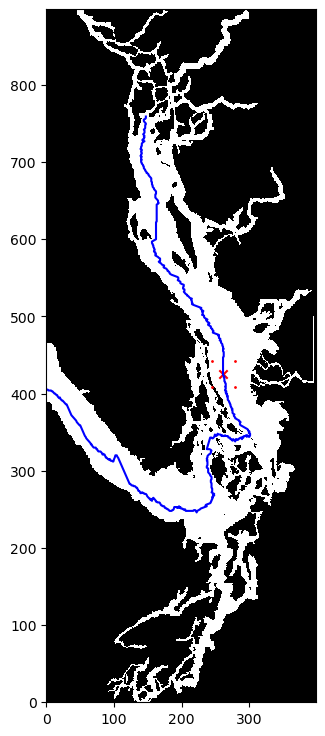

In [9]:
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
#
dd = 17
idx = 450
fig, ax = plt.subplots(figsize = (5,9))
ax.pcolormesh(mask['tmask'][0,0], cmap = cmap)
ax.set_aspect(1.14)
pylab.plot(thalweg[:,1],thalweg[:,0],color='b')
ax.scatter(thalweg[idx][1], thalweg[idx][0], c = 'r', marker = 'x')
ax.scatter(thalweg[idx][1]+dd, thalweg[idx][0]+dd, s = 1, c = 'r')
ax.scatter(thalweg[idx][1]-dd, thalweg[idx][0]-dd, s = 1, c = 'r')
ax.scatter(thalweg[idx][1]-dd, thalweg[idx][0]+dd, s = 1, c = 'r')
ax.scatter(thalweg[idx][1]+dd, thalweg[idx][0]-dd, s = 1, c = 'r')


In [9]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [10]:
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)

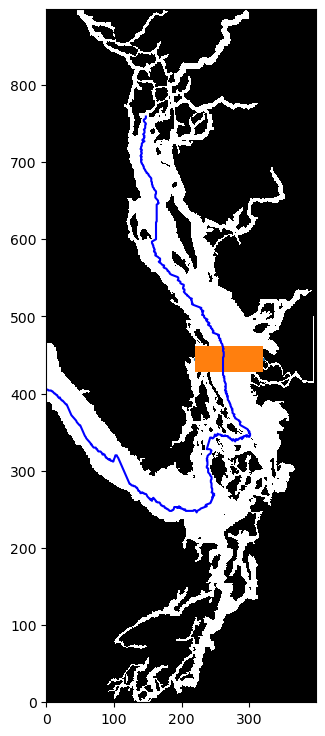

In [12]:
line_s = np.arange(220, s_x + dd)
line_y = [s_y] * len(line_s)
#
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
#
dd = 17
idx = 450
fig, ax = plt.subplots(figsize = (5,9))
ax.pcolormesh(mask['tmask'][0,0], cmap = cmap)
ax.set_aspect(1.14)
pylab.plot(thalweg[:,1],thalweg[:,0],color='b')
ax.scatter(line_s, line_y, s = 2)
ax.fill_between(line_s, y1 = s_y-dd, y2 = s_y+dd)



In [11]:
from scipy.spatial import cKDTree

def get_grid_indices_vectorized(part_lons, part_lats, mask):
    #
    grid_lats = mask.nav_lat.values.flatten()
    grid_lons = mask.nav_lon.values.flatten()
    tree = cKDTree(np.c_[grid_lats, grid_lons])
    
    #
    _, indices = tree.query(np.c_[part_lats, part_lons])
    
    #
    shape_x = mask.nav_lon.shape[1]
    return indices // shape_x, indices % shape_x

In [12]:

from matplotlib.colors import LogNorm

def create_robust_swath(data, thalweg, mask, d_km, dd=17, num_z_bins=40):
    status = data['status'].values.flatten()
    idx_wat = (status > 0) & (status < 4)
    
    p_lons = data['lon'].values.flatten()[idx_wat]
    p_lats = data['lat'].values.flatten()[idx_wat]
    p_depths = data['z'].values.flatten()[idx_wat]

    #
    p_y, p_x = get_grid_indices_vectorized(p_lons, p_lats, mask)

    # 3. Create 3D Histogram (Z, Y, X)
    y_bins = np.arange(0, mask.nav_lat.shape[0] + 1)
    x_bins = np.arange(0, mask.nav_lat.shape[1] + 1)
    z_bins = np.linspace(0, 450, num_z_bins + 1) # Adjust max depth to your bathy
    
    grid_3d, _ = np.histogramdd(
        (p_depths, p_y, p_x), 
        bins=(z_bins, y_bins, x_bins)
    )

    # 4. Swath Extraction with tmask
    tmask = mask['tmask'][0, 0].values
    swath_matrix = np.zeros((num_z_bins, len(thalweg)))

    print("Sliding swath box along thalweg...")
    for i, pt in enumerate(thalweg):
        y_c, x_c = int(pt[0]), int(pt[1])
        
        # Define box bounds with grid clipping
        y0, y1 = max(0, y_c - dd), min(grid_3d.shape[1], y_c + dd + 1)
        x0, x1 = max(0, x_c - dd), min(grid_3d.shape[2], x_c + dd + 1)
        
        # Local mask for the box
        local_mask = tmask[y0:y1, x0:x1]
        
        for k in range(num_z_bins):
            # Only sum counts where tmask == 1 (water)
            box_counts = grid_3d[k, y0:y1, x0:x1]
            swath_matrix[k, i] = np.sum(box_counts[local_mask == 1])

    return swath_matrix, z_bins

# Version 2

In [15]:
filename1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V2_year_2.nc'
vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'time', 'status']
#
data = xr.open_dataset(filename1, drop_variables=[v for v in xr.open_dataset(filename1).variables if v not in vars_to_keep])

In [19]:
def smooth_array(data, window_size=5):
    """Smooths array using a moving average while maintaining length."""
    window = np.ones(int(window_size)) / float(window_size)
    return np.convolve(data, window, 'same')

bat_mask_raw = np.array(bat_mask)
bat_mask_smooth = smooth_array(bat_mask_raw, window_size=7) 

bat_mask_smooth[0] = bat_mask_raw[0]
bat_mask_smooth[-1] = bat_mask_raw[-1]

In [21]:
thalweg_lats = mask.nav_lat.values[thalweg[:,0], thalweg[:,1]]
thalweg_lons = mask.nav_lon.values[thalweg[:,0], thalweg[:,1]]

dist_to_source = np.sqrt((thalweg_lats - source_lat)**2 + (thalweg_lons - source_lon)**2)
source_idx = np.argmin(dist_to_source)

source_dist_km = dist[source_idx]

In [18]:
swath_data, z_edges = create_robust_swath(data, thalweg, mask, dist)
z_centers = (z_edges[:-1] + z_edges[1:]) / 2

Sliding swath box along thalweg...


/tmp/ipykernel_17207/3296249026.py:11: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = plt.contourf(dist, z_centers, swath_data,


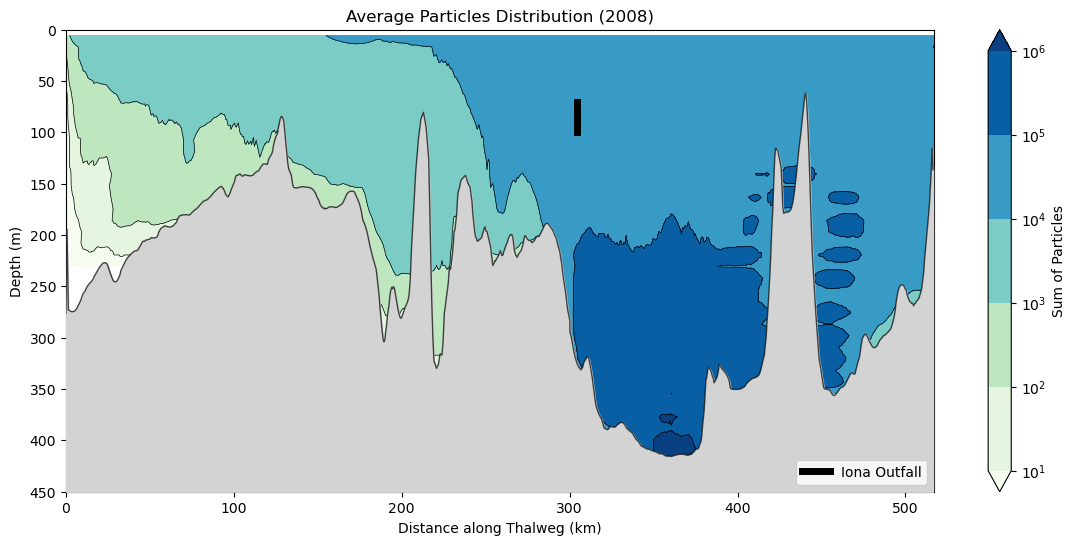

In [19]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define your specific logarithmic levels
levels = [10, 100, 1000, 10000, 100000, 1000000]

plt.figure(figsize=(14, 6))

# 1. The Particle Data using specific levels
# 'extend' ensures values above/below your levels are still colored
cntr = plt.contourf(dist, z_centers, swath_data, 
                     levels=levels, 
                     cmap='GnBu',
                     norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                     extend='both', zorder = 1)
#
lines = plt.contour(dist, z_centers, swath_data, 
                    levels=levels, 
                    colors='black', 
                    linewidths=0.5, zorder = 2)
# 2. Add the Seafloor Mask
plt.fill_between(dist[:-1], bat_mask_smooth, 450, color='lightgrey', zorder=3)
plt.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=3)
plt.plot([source_dist_km, source_dist_km], [70,100], 'k', linewidth = 5, label = 'Iona Outfall')
plt.legend(loc = 'lower right')
# 3. Formatting
plt.gca().invert_yaxis()
plt.ylim(450, 0)

# 4. Colorbar with explicit ticks matching your levels
cbar = plt.colorbar(cntr, label='Sum of Particles', ticks=levels)
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels]) # Optional: Pretty scientific notation

plt.xlabel("Distance along Thalweg (km)")
plt.ylabel("Depth (m)")
plt.title('Average Particles Distribution (2008)')

plt.show()

Plot Thalweg coverage

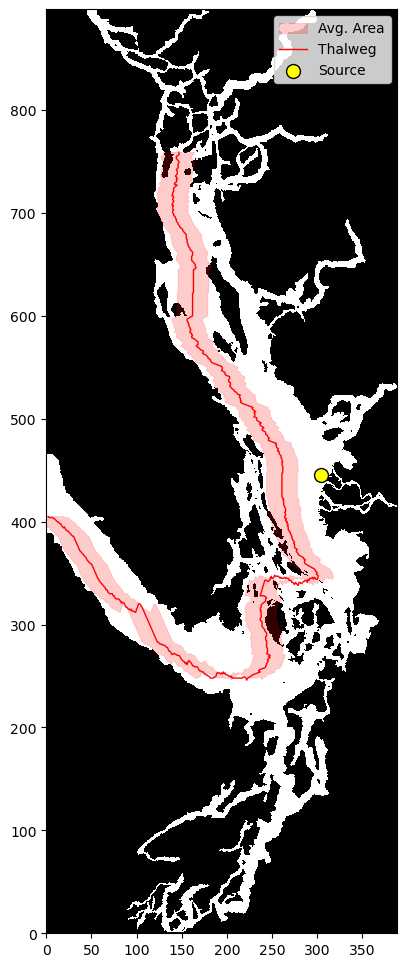

In [21]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

fig, ax = plt.subplots(figsize=(6, 12))
ax.pcolormesh(mask['tmask'][0, 0], cmap=cmap)
ax.set_aspect(1.14)

# 1. Create the 'Envelope' Coordinates
# We use the thalweg path and offset it laterally
left_side_x = thalweg[:, 1] - dd
left_side_y = thalweg[:, 0]
right_side_x = thalweg[:, 1] + dd
right_side_y = thalweg[:, 0]

# 2. Combine into a single Polygon for a clean 'Ribbon'
# We flip the right side to create a continuous loop around the thalweg
verts = [
    *zip(left_side_x, left_side_y),
    *zip(right_side_x[::-1], right_side_y[::-1])
]
poly = Polygon(verts, facecolor='red', alpha=0.2, edgecolor='r', linewidth=0.5, label='Avg. Area')
ax.add_patch(poly)

# 3. Plot the Thalweg Core
ax.plot(thalweg[:, 1], thalweg[:, 0], color='r', linewidth=1, label='Thalweg')

s_y, s_x = finder2(source_lat, source_lon, mask)
ax.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='Source')

ax.set_xlim(0,389)
ax.legend()
plt.show()

# Seasonal

In [22]:
filename = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V2_1_2_years.nc'
vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'time', 'status']
with xr.open_dataset(filename, drop_variables=[v for v in xr.open_dataset(filename).variables if v not in vars_to_keep]) as data_combined:
    idx_JFM = int((90 * 86400) / 900)
    idx_AMJ = int((181 * 86400) / 900)
    idx_JAS = int((273 * 86400) / 900)
    idx_OND = int((365 * 86400) / 900)
    # 12 months
    data_winter = data_combined.isel(trajectory=slice(0, idx_JFM), obs = slice(0, 365*8 + 90*8))
    data_spring = data_combined.isel(trajectory=slice(idx_JFM, idx_AMJ), obs = slice(90*8, 365*8 + 181*8))
    data_summer = data_combined.isel(trajectory=slice(idx_AMJ, idx_JAS), obs = slice(181*8, 365*8 + 273*8))
    data_fall = data_combined.isel(trajectory=slice(idx_JAS, idx_OND), obs = slice(273*8, 365*8 + 365*8))
    #
    # 12 months
    data_winter_last = data_combined.isel(trajectory=slice(0, idx_JFM), obs = slice(365*8, 365*8 + 8*90))
    data_spring_last = data_combined.isel(trajectory=slice(idx_JFM, idx_AMJ), obs = slice(365*8 + 90*8, 365*8 + 8*181))
    data_summer_last = data_combined.isel(trajectory=slice(idx_AMJ, idx_JAS), obs = slice(365*8 + 181*8, 365*8 + 8*273))
    data_fall_last = data_combined.isel(trajectory=slice(idx_JAS, idx_OND), obs = slice(365*8 + 273*8, 365*8 + 365*8))  

In [23]:
swath_winter, z_edges = create_robust_swath(data_winter, thalweg, mask, dist)
z_centers_winter = (z_edges[:-1] + z_edges[1:]) / 2
#
swath_spring, z_edges = create_robust_swath(data_spring, thalweg, mask, dist)
z_centers_spring = (z_edges[:-1] + z_edges[1:]) / 2
#
swath_summer, z_edges = create_robust_swath(data_summer, thalweg, mask, dist)
z_centers_summer = (z_edges[:-1] + z_edges[1:]) / 2
#
swath_fall, z_edges = create_robust_swath(data_fall, thalweg, mask, dist)
z_centers_fall = (z_edges[:-1] + z_edges[1:]) / 2

Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...


/tmp/ipykernel_17207/3773226170.py:11: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = plt.contourf(dist, z_centers_winter, swath_winter,


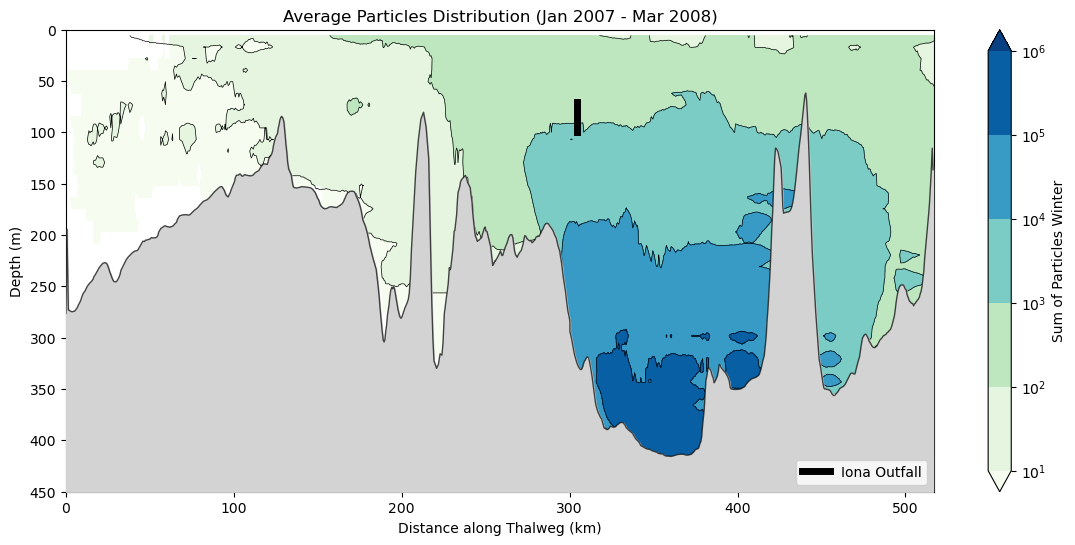

In [24]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define your specific logarithmic levels
levels = [10, 100, 1000, 10000, 100000, 1000000]

plt.figure(figsize=(14, 6))

# 1. The Particle Data using specific levels
# 'extend' ensures values above/below your levels are still colored
cntr = plt.contourf(dist, z_centers_winter, swath_winter, 
                     levels=levels, 
                     cmap='GnBu',
                     norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                     extend='both', zorder = 1)
#
lines = plt.contour(dist, z_centers_winter, swath_winter, 
                    levels=levels, 
                    colors='black', 
                    linewidths=0.5, zorder = 2)
# 2. Add the Seafloor Mask
plt.fill_between(dist[:-1], bat_mask_smooth, 450, color='lightgrey', zorder=3)
plt.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=3)
plt.plot([source_dist_km, source_dist_km], [70,100], 'k', linewidth = 5, label = 'Iona Outfall')
plt.legend(loc = 'lower right')
# 3. Formatting
plt.gca().invert_yaxis()
plt.ylim(450, 0)

# 4. Colorbar with explicit ticks matching your levels
cbar = plt.colorbar(cntr, label='Sum of Particles Winter', ticks=levels)
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels]) # Optional: Pretty scientific notation

plt.xlabel("Distance along Thalweg (km)")
plt.ylabel("Depth (m)")
plt.title('Average Particles Distribution (Jan 2007 - Mar 2008)')

plt.show()

/tmp/ipykernel_17207/180609988.py:11: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = plt.contourf(dist, z_centers_spring, swath_spring,


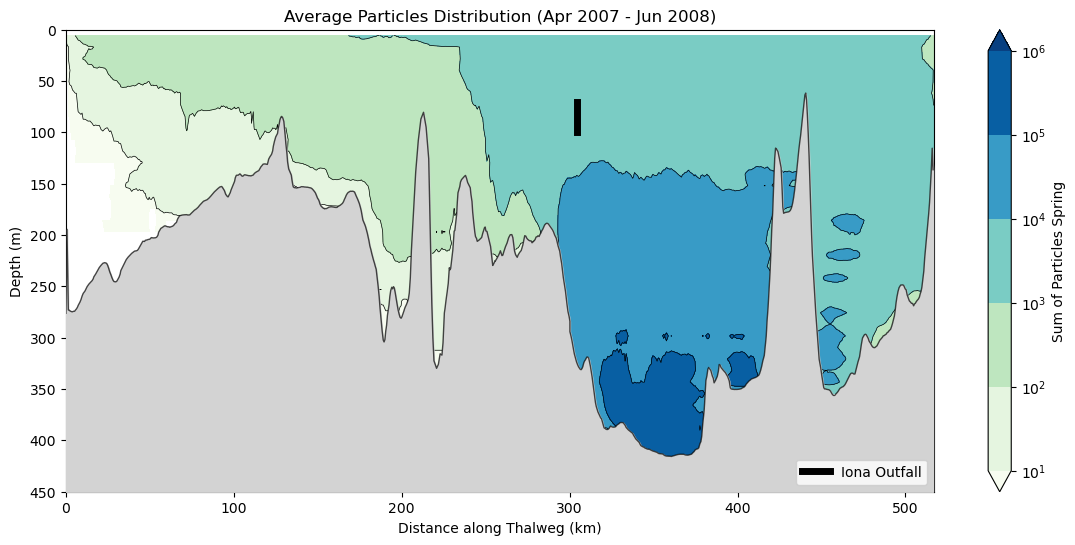

In [25]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define your specific logarithmic levels
levels = [10, 100, 1000, 10000, 100000, 1000000]

plt.figure(figsize=(14, 6))

# 1. The Particle Data using specific levels
# 'extend' ensures values above/below your levels are still colored
cntr = plt.contourf(dist, z_centers_spring, swath_spring, 
                     levels=levels, 
                     cmap='GnBu',
                     norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                     extend='both', zorder = 1)
#
lines = plt.contour(dist, z_centers_spring, swath_spring, 
                    levels=levels, 
                    colors='black', 
                    linewidths=0.5, zorder = 2)
# 2. Add the Seafloor Mask
plt.fill_between(dist[:-1], bat_mask_smooth, 450, color='lightgrey', zorder=3)
plt.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=3)
plt.plot([source_dist_km, source_dist_km], [70,100], 'k', linewidth = 5, label = 'Iona Outfall')
plt.legend(loc = 'lower right')
# 3. Formatting
plt.gca().invert_yaxis()
plt.ylim(450, 0)

# 4. Colorbar with explicit ticks matching your levels
cbar = plt.colorbar(cntr, label='Sum of Particles Spring', ticks=levels)
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels]) # Optional: Pretty scientific notation

plt.xlabel("Distance along Thalweg (km)")
plt.ylabel("Depth (m)")
plt.title('Average Particles Distribution (Apr 2007 - Jun 2008)')

plt.show()

/tmp/ipykernel_17207/1114828036.py:11: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = plt.contourf(dist, z_centers_summer, swath_summer,


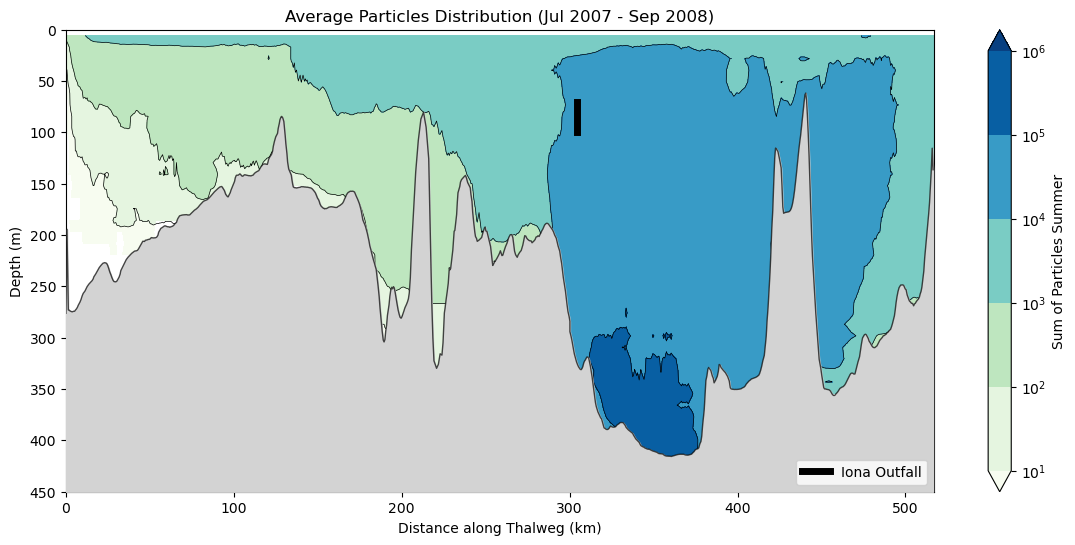

In [26]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define your specific logarithmic levels
levels = [10, 100, 1000, 10000, 100000, 1000000]

plt.figure(figsize=(14, 6))

# 1. The Particle Data using specific levels
# 'extend' ensures values above/below your levels are still colored
cntr = plt.contourf(dist, z_centers_summer, swath_summer, 
                     levels=levels, 
                     cmap='GnBu',
                     norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                     extend='both', zorder = 1)
#
lines = plt.contour(dist, z_centers_summer, swath_summer, 
                    levels=levels, 
                    colors='black', 
                    linewidths=0.5, zorder = 2)
# 2. Add the Seafloor Mask
plt.fill_between(dist[:-1], bat_mask_smooth, 450, color='lightgrey', zorder=3)
plt.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=3)
plt.plot([source_dist_km, source_dist_km], [70,100], 'k', linewidth = 5, label = 'Iona Outfall')
plt.legend(loc = 'lower right')
# 3. Formatting
plt.gca().invert_yaxis()
plt.ylim(450, 0)

# 4. Colorbar with explicit ticks matching your levels
cbar = plt.colorbar(cntr, label='Sum of Particles Summer', ticks=levels)
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels]) # Optional: Pretty scientific notation

plt.xlabel("Distance along Thalweg (km)")
plt.ylabel("Depth (m)")
plt.title('Average Particles Distribution (Jul 2007 - Sep 2008)')

plt.show()

/tmp/ipykernel_17207/4067379141.py:11: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = plt.contourf(dist, z_centers_fall, swath_fall,


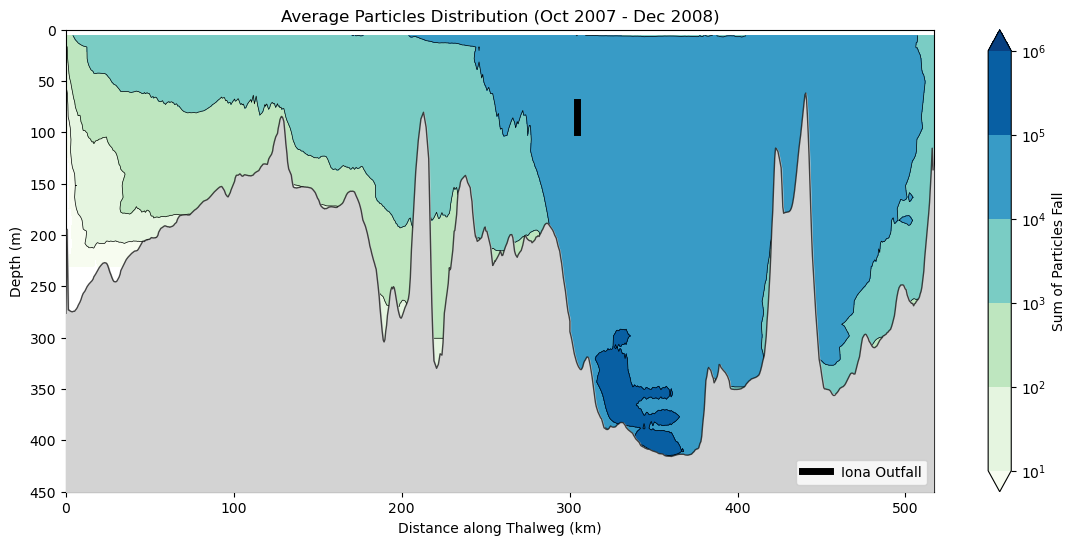

In [27]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define your specific logarithmic levels
levels = [10, 100, 1000, 10000, 100000, 1000000]

plt.figure(figsize=(14, 6))

# 1. The Particle Data using specific levels
# 'extend' ensures values above/below your levels are still colored
cntr = plt.contourf(dist, z_centers_fall, swath_fall, 
                     levels=levels, 
                     cmap='GnBu',
                     norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                     extend='both', zorder = 1)
#
lines = plt.contour(dist, z_centers_fall, swath_fall, 
                    levels=levels, 
                    colors='black', 
                    linewidths=0.5, zorder = 2)
# 2. Add the Seafloor Mask
plt.fill_between(dist[:-1], bat_mask_smooth, 450, color='lightgrey', zorder=3)
plt.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=3)
plt.plot([source_dist_km, source_dist_km], [70,100], 'k', linewidth = 5, label = 'Iona Outfall')
plt.legend(loc = 'lower right')
# 3. Formatting
plt.gca().invert_yaxis()
plt.ylim(450, 0)

# 4. Colorbar with explicit ticks matching your levels
cbar = plt.colorbar(cntr, label='Sum of Particles Fall', ticks=levels)
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels]) # Optional: Pretty scientific notation

plt.xlabel("Distance along Thalweg (km)")
plt.ylabel("Depth (m)")
plt.title('Average Particles Distribution (Oct 2007 - Dec 2008)')

plt.show()

# First year evolution

In [28]:
with xr.open_dataset(filename, drop_variables=[v for v in xr.open_dataset(filename).variables if v not in vars_to_keep]) as data_combined:
    data_week1 = data_combined.isel(obs = slice(0,56))
    data_week2 = data_combined.isel(obs = slice(0,112))
    data_month1 = data_combined.isel(obs = slice(0, 8*30))
    data_month3 = data_combined.isel(obs = slice(0, 8*90))
    data_month6 = data_combined.isel(obs = slice(0, 8*180))
    data_month9 = data_combined.isel(obs = slice(0, 8*270))
    data_month12 = data_combined.isel(obs = slice(0, 8*365))

In [29]:
swath_week1, z_week1 = create_robust_swath(data_week1, thalweg, mask, dist)
z_centers_week1 = (z_week1[:-1] + z_week1[1:]) / 2
#
swath_week2, z_week2 = create_robust_swath(data_week2, thalweg, mask, dist)
z_centers_week2 = (z_week2[:-1] + z_week2[1:]) / 2
#
swath_month1, z_month1 = create_robust_swath(data_month1, thalweg, mask, dist)
z_centers_month1 = (z_month1[:-1] + z_month1[1:]) / 2
#
swath_month3, z_month3 = create_robust_swath(data_month3, thalweg, mask, dist)
z_centers_month3 = (z_month3[:-1] + z_month3[1:]) / 2
#
swath_month6, z_month6 = create_robust_swath(data_month6, thalweg, mask, dist)
z_centers_month6 = (z_month6[:-1] + z_month6[1:]) / 2
#
swath_month9, z_month9 = create_robust_swath(data_month9, thalweg, mask, dist)
z_centers_month9 = (z_month9[:-1] + z_month9[1:]) / 2
#
swath_month12, z_month12 = create_robust_swath(data_month12, thalweg, mask, dist)
z_centers_month12 = (z_month12[:-1] + z_month12[1:]) / 2

Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...


In [30]:
z_list = [z_centers_week1, z_centers_week2, z_centers_month1, z_centers_month3, z_centers_month6, z_centers_month9, z_centers_month12]
swath_list = [swath_week1, swath_week2, swath_month1, swath_month3, swath_month6, swath_month9, swath_month12]

/tmp/ipykernel_17207/3721952000.py:21: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = ax.contourf(dist, z_list[i], current_swath,


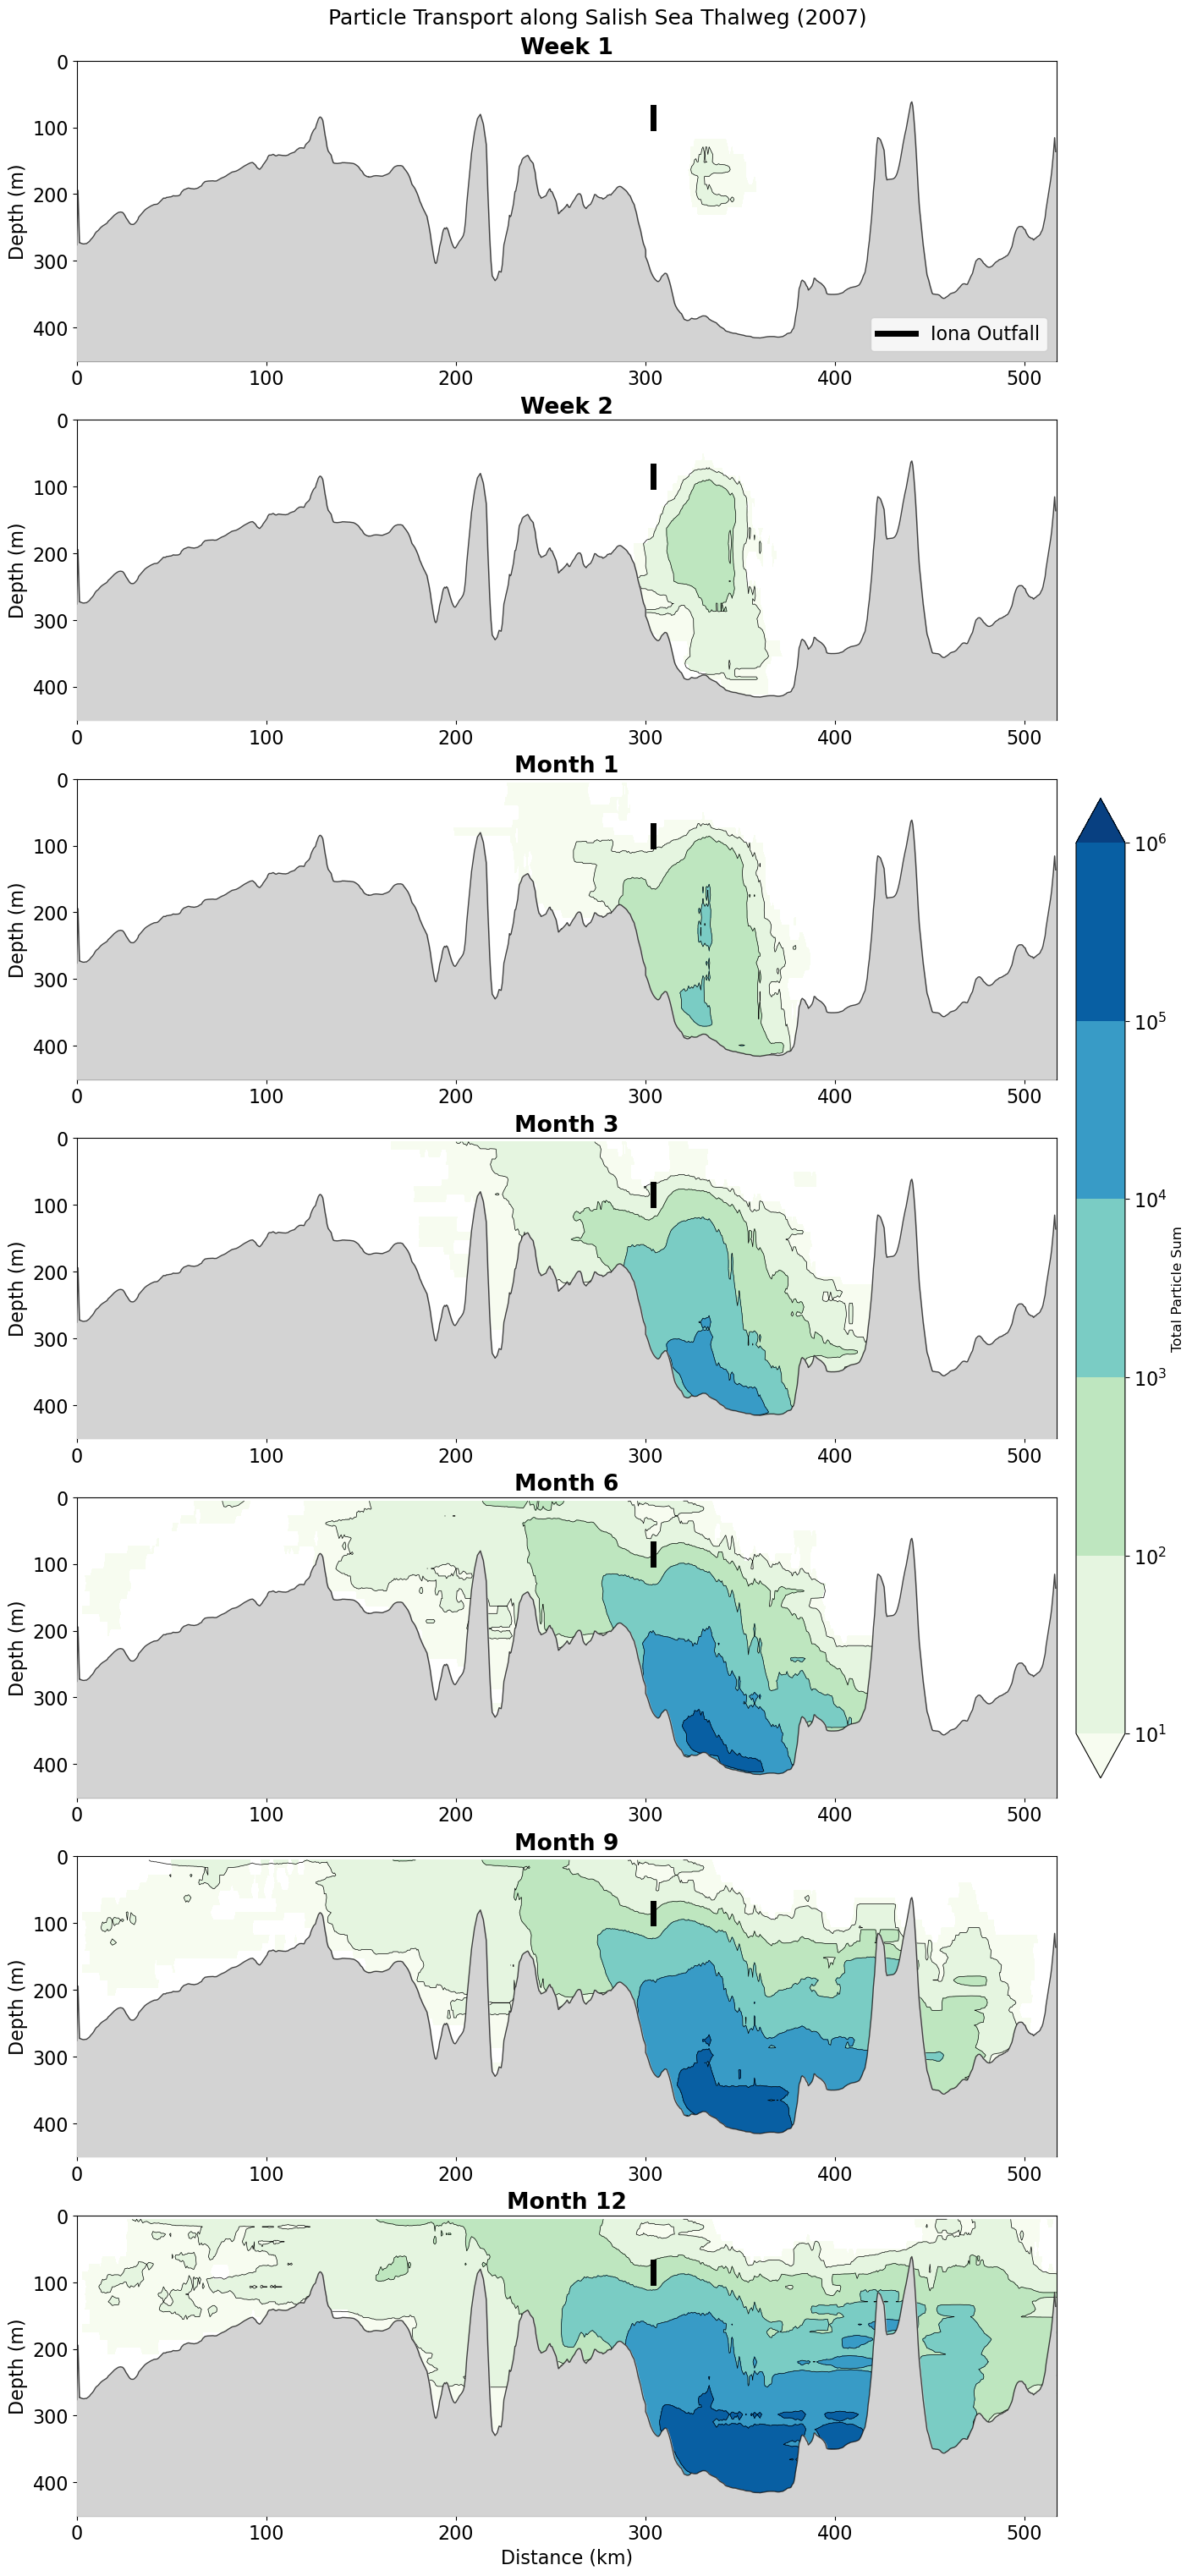

In [31]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
plt.rcParams.update({'font.size': 16})
# 1. Configuration
time_labels = ['Week 1', 'Week 2', 'Month 1', 'Month 3', 'Month 6', 'Month 9', 'Month 12']
levels = [10, 100, 1000, 10000, 100000, 1000000]

# Use layout='constrained' to prevent titles/labels from overlapping
fig, axes = plt.subplots(7, 1, figsize=(14, 30), layout='constrained')

for i in range(len(swath_list)):
    ax = axes[i]
    
    # Handle dimension alignment
    # We ensure the columns of the data match the length of the distance array
    current_swath = swath_list[i] if swath_list[i].shape[1] == len(dist) else swath_list[i].T
    
    # 2. Plotting the Particle Data
    # We save the 'cntr' object from the plots to use for the single colorbar
    cntr = ax.contourf(dist, z_list[i], current_swath, 
                       levels=levels, 
                       cmap='GnBu',
                       norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                       extend='both', zorder=1)
    
    # 3. Line Contours for clarity
    ax.contour(dist, z_list[i], current_swath, 
               levels=levels, 
               colors='black', 
               linewidths=0.5, zorder=2)
    
    # 4. Bathymetry Mask
    ax.fill_between(dist[:-1], bat_mask_smooth, 450, color='lightgrey', zorder=3)
    ax.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=4)
    
    # 5. Outfall Marker (Vertical line at the source distance)
    ax.plot([source_dist_km, source_dist_km], [70,100], 'k', linewidth = 5, label = 'Iona Outfall')
    
    # 6. Per-panel Formatting
    ax.invert_yaxis()
    ax.set_ylim(450, 0)
    ax.set_xlim(dist.min(), dist.max())
    ax.set_ylabel("Depth (m)")
    ax.set_title(f'{time_labels[i]}', fontweight='bold')
    
    if i == 0:
        ax.legend(loc='lower right')
    if i == 6:
        ax.set_xlabel('Distance (km)')    

# 7. THE MASTER COLORBAR
# 'ax=axes' tells matplotlib to steal space from all subplots equally
cbar = fig.colorbar(cntr, ax=axes, orientation='vertical', fraction=0.05, pad=0.02, ticks=levels)
cbar.set_label('Total Particle Sum', fontsize=12)

# Set the tick labels to scientific notation for readability
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels])

plt.suptitle('Particle Transport along Salish Sea Thalweg (2007)', fontsize=18, y=1.01)
plt.show()

# Version 4

In [16]:
filename = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_years_1_and_2.nc'
vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'time', 'status']
with xr.open_dataset(filename, drop_variables=[v for v in xr.open_dataset(filename).variables if v not in vars_to_keep]) as data_combined:
    idx_JFM = int((90 * 86400) / 900)
    idx_AMJ = int((181 * 86400) / 900)
    idx_JAS = int((273 * 86400) / 900)
    idx_OND = int((365 * 86400) / 900)
    # 12 months
    data_winter = data_combined.isel(trajectory=slice(0, idx_JFM), obs = slice(0, 365*8 + 90*8))
    data_spring = data_combined.isel(trajectory=slice(idx_JFM, idx_AMJ), obs = slice(90*8, 365*8 + 181*8))
    data_summer = data_combined.isel(trajectory=slice(idx_AMJ, idx_JAS), obs = slice(181*8, 365*8 + 273*8))
    data_fall = data_combined.isel(trajectory=slice(idx_JAS, idx_OND), obs = slice(273*8, 365*8 + 365*8))
    #
    # 12 months
    data_winter_last = data_combined.isel(trajectory=slice(0, idx_JFM), obs = slice(365*8, 365*8 + 8*90))
    data_spring_last = data_combined.isel(trajectory=slice(idx_JFM, idx_AMJ), obs = slice(365*8 + 90*8, 365*8 + 8*181))
    data_summer_last = data_combined.isel(trajectory=slice(idx_AMJ, idx_JAS), obs = slice(365*8 + 181*8, 365*8 + 8*273))
    data_fall_last = data_combined.isel(trajectory=slice(idx_JAS, idx_OND), obs = slice(365*8 + 273*8, 365*8 + 365*8))  

In [33]:
swath_winter, z_edges = create_robust_swath(data_winter, thalweg, mask, dist)
z_centers_winter = (z_edges[:-1] + z_edges[1:]) / 2
#
swath_spring, z_edges = create_robust_swath(data_spring, thalweg, mask, dist)
z_centers_spring = (z_edges[:-1] + z_edges[1:]) / 2
#
swath_summer, z_edges = create_robust_swath(data_summer, thalweg, mask, dist)
z_centers_summer = (z_edges[:-1] + z_edges[1:]) / 2
#
swath_fall, z_edges = create_robust_swath(data_fall, thalweg, mask, dist)
z_centers_fall = (z_edges[:-1] + z_edges[1:]) / 2

Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...


/tmp/ipykernel_17207/3773226170.py:11: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = plt.contourf(dist, z_centers_winter, swath_winter,


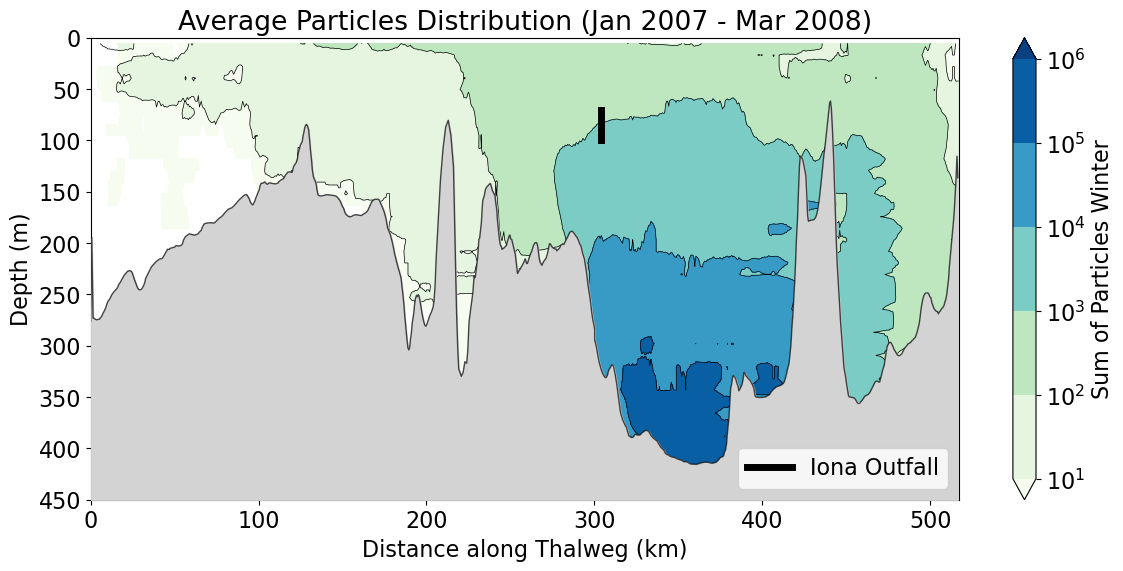

In [34]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define your specific logarithmic levels
levels = [10, 100, 1000, 10000, 100000, 1000000]

plt.figure(figsize=(14, 6))

# 1. The Particle Data using specific levels
# 'extend' ensures values above/below your levels are still colored
cntr = plt.contourf(dist, z_centers_winter, swath_winter, 
                     levels=levels, 
                     cmap='GnBu',
                     norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                     extend='both', zorder = 1)
#
lines = plt.contour(dist, z_centers_winter, swath_winter, 
                    levels=levels, 
                    colors='black', 
                    linewidths=0.5, zorder = 2)
# 2. Add the Seafloor Mask
plt.fill_between(dist[:-1], bat_mask_smooth, 450, color='lightgrey', zorder=3)
plt.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=3)
plt.plot([source_dist_km, source_dist_km], [70,100], 'k', linewidth = 5, label = 'Iona Outfall')
plt.legend(loc = 'lower right')
# 3. Formatting
plt.gca().invert_yaxis()
plt.ylim(450, 0)

# 4. Colorbar with explicit ticks matching your levels
cbar = plt.colorbar(cntr, label='Sum of Particles Winter', ticks=levels)
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels]) # Optional: Pretty scientific notation

plt.xlabel("Distance along Thalweg (km)")
plt.ylabel("Depth (m)")
plt.title('Average Particles Distribution (Jan 2007 - Mar 2008)')

plt.show()

/tmp/ipykernel_17207/180609988.py:11: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = plt.contourf(dist, z_centers_spring, swath_spring,


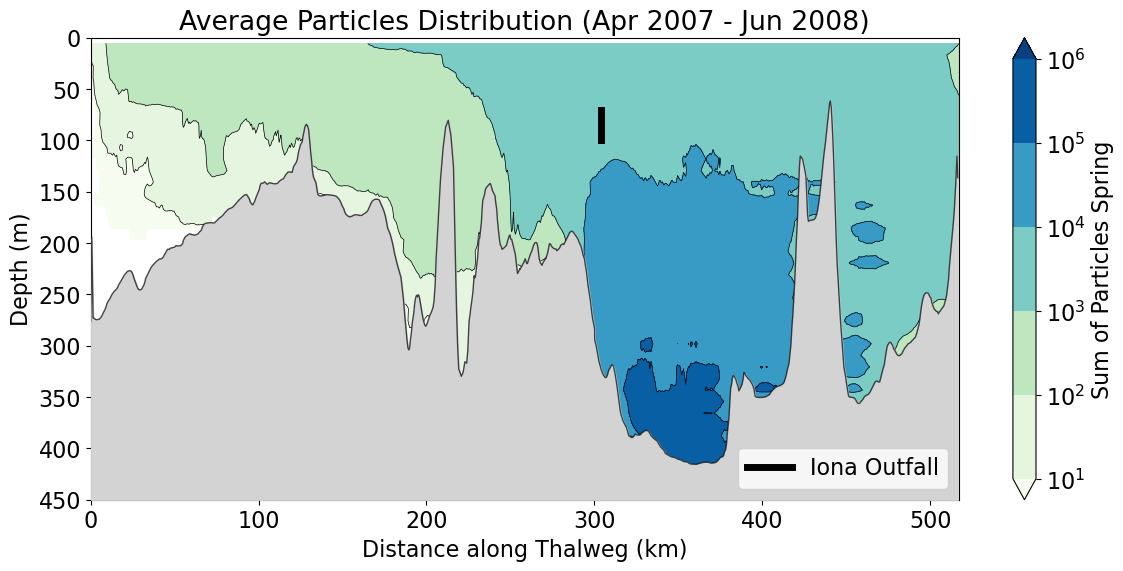

In [35]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define your specific logarithmic levels
levels = [10, 100, 1000, 10000, 100000, 1000000]

plt.figure(figsize=(14, 6))

# 1. The Particle Data using specific levels
# 'extend' ensures values above/below your levels are still colored
cntr = plt.contourf(dist, z_centers_spring, swath_spring, 
                     levels=levels, 
                     cmap='GnBu',
                     norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                     extend='both', zorder = 1)
#
lines = plt.contour(dist, z_centers_spring, swath_spring, 
                    levels=levels, 
                    colors='black', 
                    linewidths=0.5, zorder = 2)
# 2. Add the Seafloor Mask
plt.fill_between(dist[:-1], bat_mask_smooth, 450, color='lightgrey', zorder=3)
plt.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=3)
plt.plot([source_dist_km, source_dist_km], [70,100], 'k', linewidth = 5, label = 'Iona Outfall')
plt.legend(loc = 'lower right')
# 3. Formatting
plt.gca().invert_yaxis()
plt.ylim(450, 0)

# 4. Colorbar with explicit ticks matching your levels
cbar = plt.colorbar(cntr, label='Sum of Particles Spring', ticks=levels)
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels]) # Optional: Pretty scientific notation

plt.xlabel("Distance along Thalweg (km)")
plt.ylabel("Depth (m)")
plt.title('Average Particles Distribution (Apr 2007 - Jun 2008)')

plt.show()

/tmp/ipykernel_17207/1114828036.py:11: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = plt.contourf(dist, z_centers_summer, swath_summer,


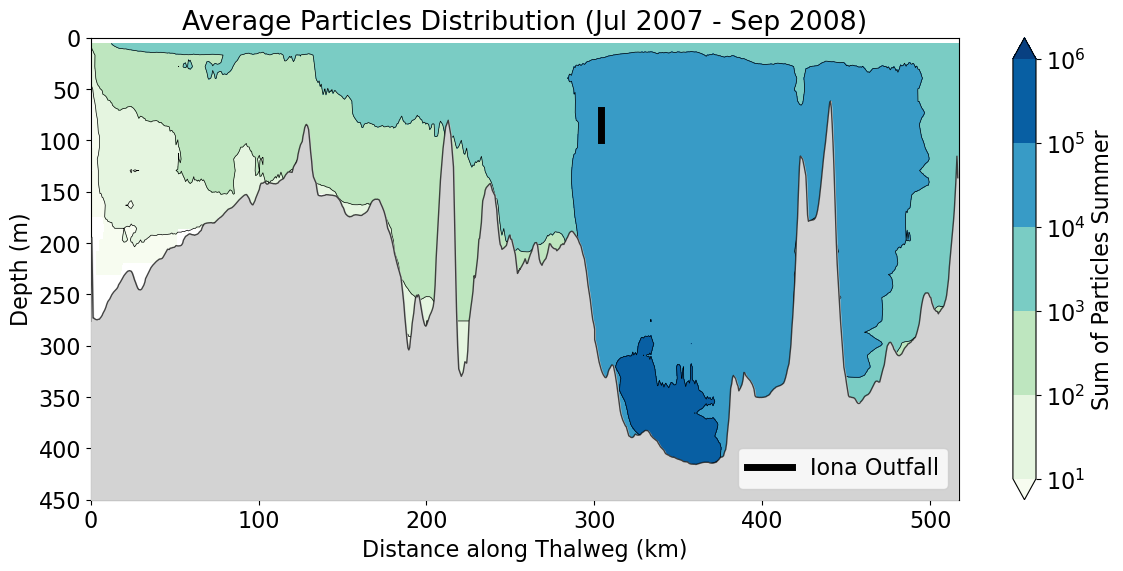

In [36]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define your specific logarithmic levels
levels = [10, 100, 1000, 10000, 100000, 1000000]

plt.figure(figsize=(14, 6))

# 1. The Particle Data using specific levels
# 'extend' ensures values above/below your levels are still colored
cntr = plt.contourf(dist, z_centers_summer, swath_summer, 
                     levels=levels, 
                     cmap='GnBu',
                     norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                     extend='both', zorder = 1)
#
lines = plt.contour(dist, z_centers_summer, swath_summer, 
                    levels=levels, 
                    colors='black', 
                    linewidths=0.5, zorder = 2)
# 2. Add the Seafloor Mask
plt.fill_between(dist[:-1], bat_mask_smooth, 450, color='lightgrey', zorder=3)
plt.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=3)
plt.plot([source_dist_km, source_dist_km], [70,100], 'k', linewidth = 5, label = 'Iona Outfall')
plt.legend(loc = 'lower right')
# 3. Formatting
plt.gca().invert_yaxis()
plt.ylim(450, 0)

# 4. Colorbar with explicit ticks matching your levels
cbar = plt.colorbar(cntr, label='Sum of Particles Summer', ticks=levels)
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels]) # Optional: Pretty scientific notation

plt.xlabel("Distance along Thalweg (km)")
plt.ylabel("Depth (m)")
plt.title('Average Particles Distribution (Jul 2007 - Sep 2008)')

plt.show()

/tmp/ipykernel_17207/4067379141.py:11: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = plt.contourf(dist, z_centers_fall, swath_fall,


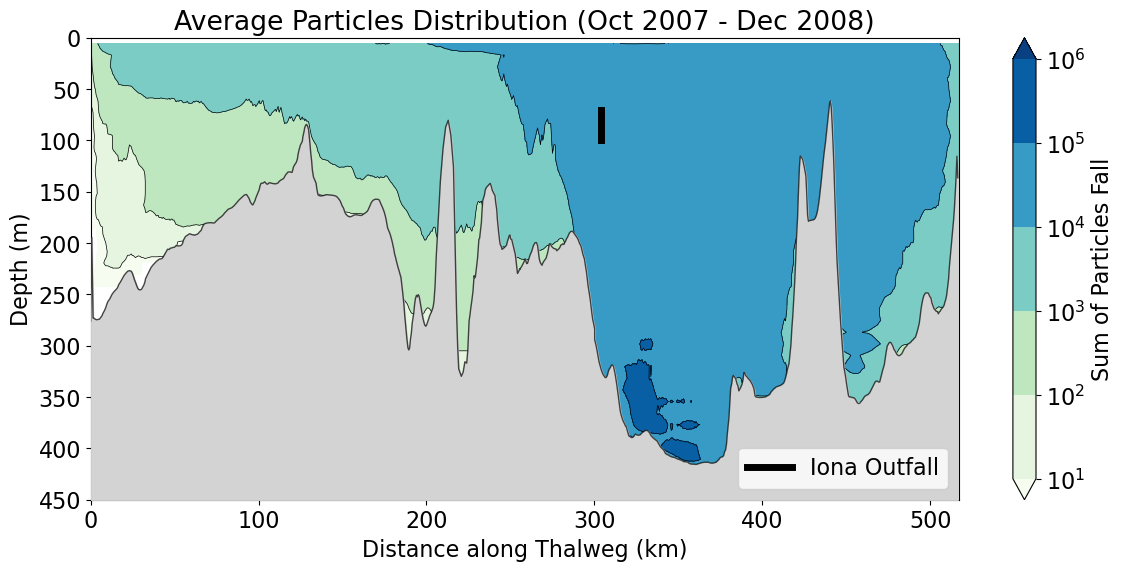

In [37]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Define your specific logarithmic levels
levels = [10, 100, 1000, 10000, 100000, 1000000]

plt.figure(figsize=(14, 6))

# 1. The Particle Data using specific levels
# 'extend' ensures values above/below your levels are still colored
cntr = plt.contourf(dist, z_centers_fall, swath_fall, 
                     levels=levels, 
                     cmap='GnBu',
                     norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                     extend='both', zorder = 1)
#
lines = plt.contour(dist, z_centers_fall, swath_fall, 
                    levels=levels, 
                    colors='black', 
                    linewidths=0.5, zorder = 2)
# 2. Add the Seafloor Mask
plt.fill_between(dist[:-1], bat_mask_smooth, 450, color='lightgrey', zorder=3)
plt.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=3)
plt.plot([source_dist_km, source_dist_km], [70,100], 'k', linewidth = 5, label = 'Iona Outfall')
plt.legend(loc = 'lower right')
# 3. Formatting
plt.gca().invert_yaxis()
plt.ylim(450, 0)

# 4. Colorbar with explicit ticks matching your levels
cbar = plt.colorbar(cntr, label='Sum of Particles Fall', ticks=levels)
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels]) # Optional: Pretty scientific notation

plt.xlabel("Distance along Thalweg (km)")
plt.ylabel("Depth (m)")
plt.title('Average Particles Distribution (Oct 2007 - Dec 2008)')

plt.show()

In [15]:
filename = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V4_years_1_and_2.nc'
vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'time', 'status']
with xr.open_dataset(filename, drop_variables=[v for v in xr.open_dataset(filename).variables if v not in vars_to_keep]) as data_combined:
    data_week1 = data_combined.isel(obs = slice(0,56))
    data_week2 = data_combined.isel(obs = slice(0,112))
    data_month1 = data_combined.isel(obs = slice(0, 8*30))
    data_month3 = data_combined.isel(obs = slice(0, 8*90))
    data_month6 = data_combined.isel(obs = slice(0, 8*180))
    data_month9 = data_combined.isel(obs = slice(0, 8*270))
    data_month12 = data_combined.isel(obs = slice(0, 8*365))
    data_month13 = data_combined.isel(obs = slice(0, 8*396))
    data_month14 = data_combined.isel(obs = slice(0, 8*426))

In [16]:
swath_week1, z_week1 = create_robust_swath(data_week1, thalweg, mask, dist)
z_centers_week1 = (z_week1[:-1] + z_week1[1:]) / 2
#
swath_week2, z_week2 = create_robust_swath(data_week2, thalweg, mask, dist)
z_centers_week2 = (z_week2[:-1] + z_week2[1:]) / 2
#
swath_month1, z_month1 = create_robust_swath(data_month1, thalweg, mask, dist)
z_centers_month1 = (z_month1[:-1] + z_month1[1:]) / 2
#
swath_month3, z_month3 = create_robust_swath(data_month3, thalweg, mask, dist)
z_centers_month3 = (z_month3[:-1] + z_month3[1:]) / 2
#
swath_month6, z_month6 = create_robust_swath(data_month6, thalweg, mask, dist)
z_centers_month6 = (z_month6[:-1] + z_month6[1:]) / 2
#
swath_month9, z_month9 = create_robust_swath(data_month9, thalweg, mask, dist)
z_centers_month9 = (z_month9[:-1] + z_month9[1:]) / 2
#
swath_month12, z_month12 = create_robust_swath(data_month12, thalweg, mask, dist)
z_centers_month12 = (z_month12[:-1] + z_month12[1:]) / 2
#
swath_month13, z_month13 = create_robust_swath(data_month13, thalweg, mask, dist)
z_centers_month13 = (z_month13[:-1] + z_month13[1:]) / 2
#
swath_month14, z_month14 = create_robust_swath(data_month14, thalweg, mask, dist)
z_centers_month14 = (z_month14[:-1] + z_month14[1:]) / 2


Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...


In [17]:
z_list = [z_centers_week1, z_centers_week2, z_centers_month1, z_centers_month3, z_centers_month6, z_centers_month9, z_centers_month12, 
          z_centers_month13, z_centers_month14]
swath_list = [swath_week1, swath_week2, swath_month1, swath_month3, swath_month6, swath_month9, swath_month12, swath_month13, 
              swath_month14]

/tmp/ipykernel_1495019/3845647708.py:21: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = ax.contourf(dist, z_list[i], current_swath,


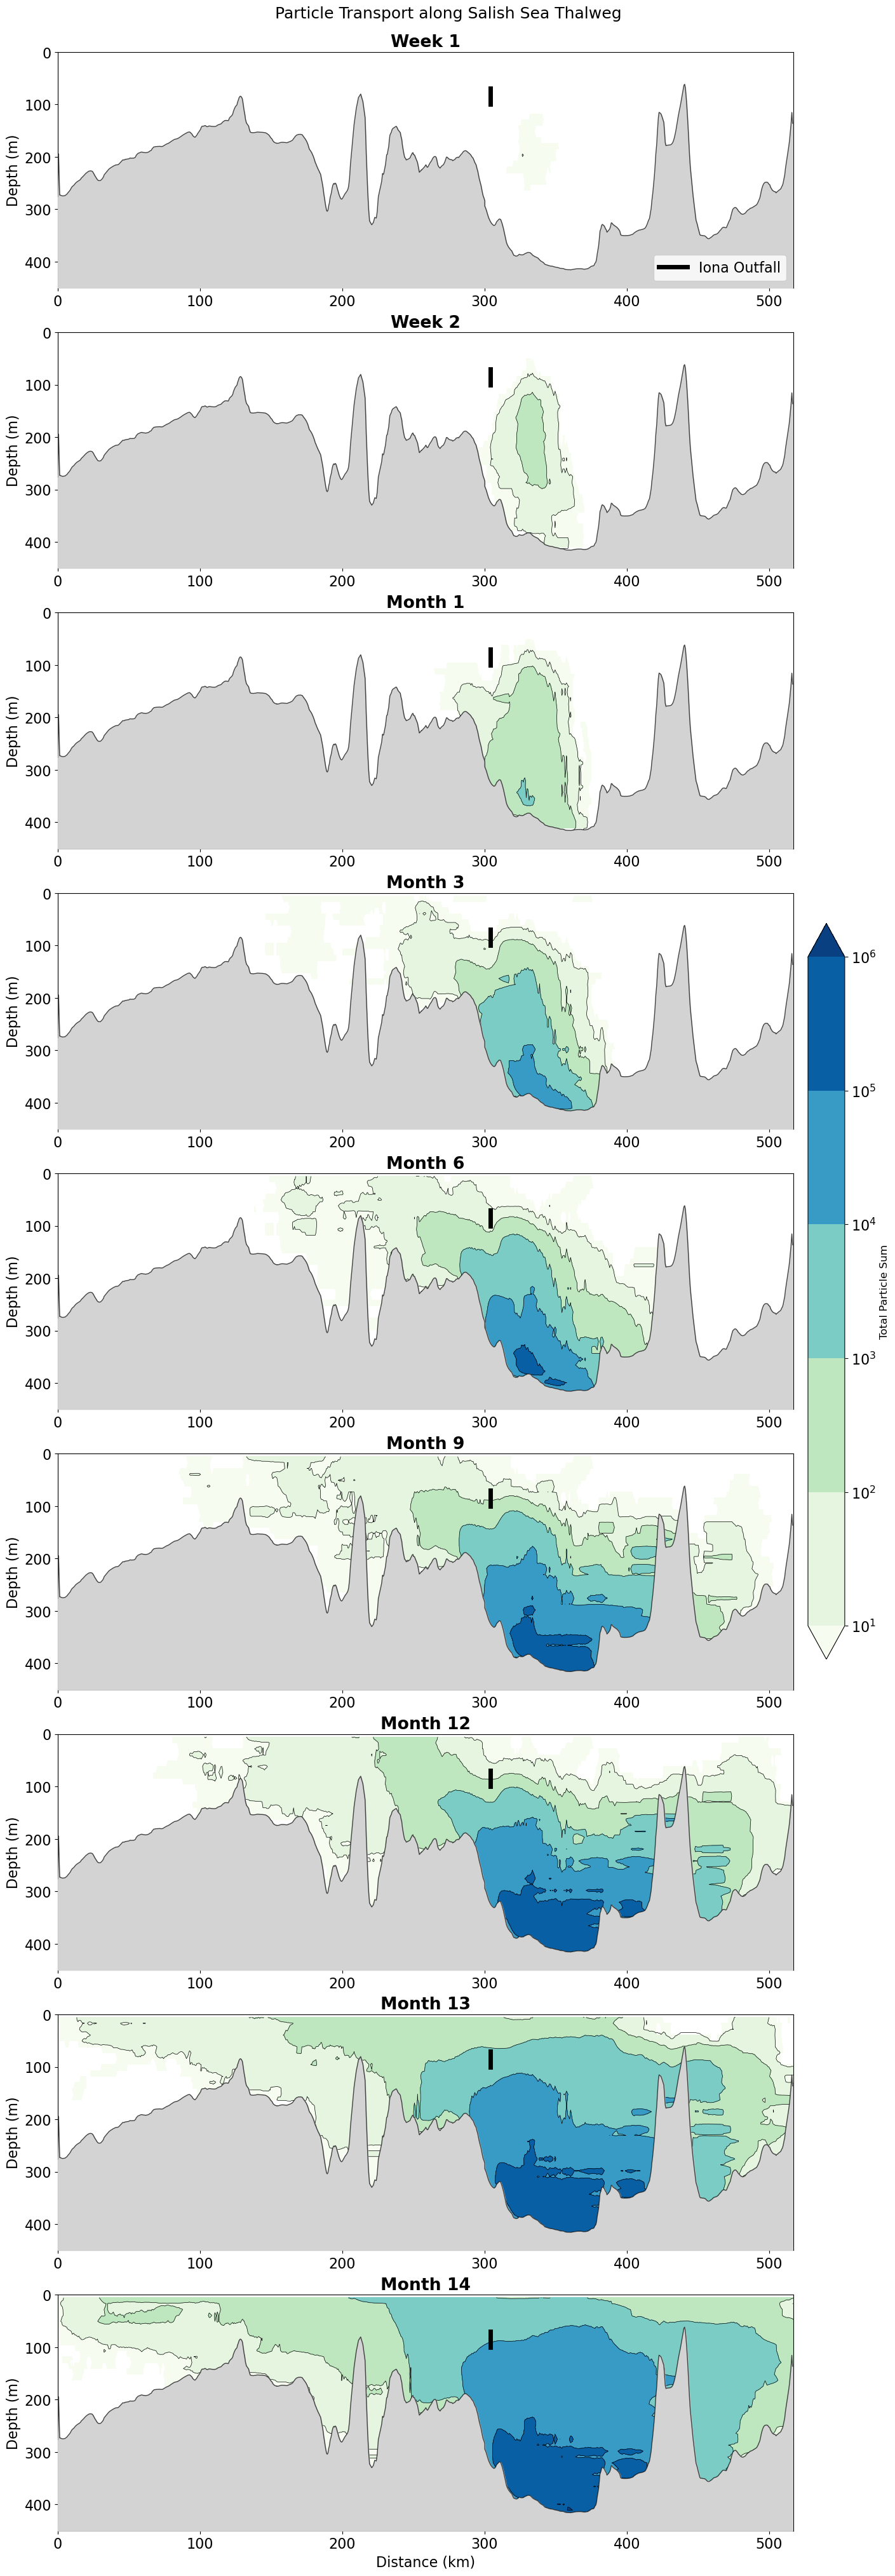

In [22]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
plt.rcParams.update({'font.size': 16})
# 1. Configuration
time_labels = ['Week 1', 'Week 2', 'Month 1', 'Month 3', 'Month 6', 'Month 9', 'Month 12', 'Month 13', 'Month 14']
levels = [10, 100, 1000, 10000, 100000, 1000000]

# Use layout='constrained' to prevent titles/labels from overlapping
fig, axes = plt.subplots(9, 1, figsize=(14, 40), layout='constrained')

for i in range(len(swath_list)):
    ax = axes[i]
    
    # Handle dimension alignment
    # We ensure the columns of the data match the length of the distance array
    current_swath = swath_list[i] if swath_list[i].shape[1] == len(dist) else swath_list[i].T
    
    # 2. Plotting the Particle Data
    # We save the 'cntr' object from the plots to use for the single colorbar
    cntr = ax.contourf(dist, z_list[i], current_swath, 
                       levels=levels, 
                       cmap='GnBu',
                       norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                       extend='both', zorder=1)
    
    # 3. Line Contours for clarity
    ax.contour(dist, z_list[i], current_swath, 
               levels=levels, 
               colors='black', 
               linewidths=0.5, zorder=2)
    
    # 4. Bathymetry Mask
    ax.fill_between(dist[:-1], bat_mask_smooth, 450, color='lightgrey', zorder=3)
    ax.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=4)
    
    # 5. Outfall Marker (Vertical line at the source distance)
    ax.plot([source_dist_km, source_dist_km], [70,100], 'k', linewidth = 5, label = 'Iona Outfall')
    
    # 6. Per-panel Formatting
    ax.invert_yaxis()
    ax.set_ylim(450, 0)
    ax.set_xlim(dist.min(), dist.max())
    ax.set_ylabel("Depth (m)")
    ax.set_title(f'{time_labels[i]}', fontweight='bold')
    
    if i == 0:
        ax.legend(loc='lower right')
    if i == 8:
        ax.set_xlabel('Distance (km)')    

# 7. THE MASTER COLORBAR
# 'ax=axes' tells matplotlib to steal space from all subplots equally
cbar = fig.colorbar(cntr, ax=axes, orientation='vertical', fraction=0.05, pad=0.02, ticks=levels)
cbar.set_label('Total Particle Sum', fontsize=12)

# Set the tick labels to scientific notation for readability
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels])

plt.suptitle('Particle Transport along Salish Sea Thalweg', fontsize=18, y=1.01)
plt.show()

# Cross-Sections 

In [68]:
filename1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Simulation_V2_year_1.nc'
vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'time', 'status']
#
data = xr.open_dataset(filename1, drop_variables=[v for v in xr.open_dataset(filename1).variables if v not in vars_to_keep])

In [50]:
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)
s_x = s_x-1

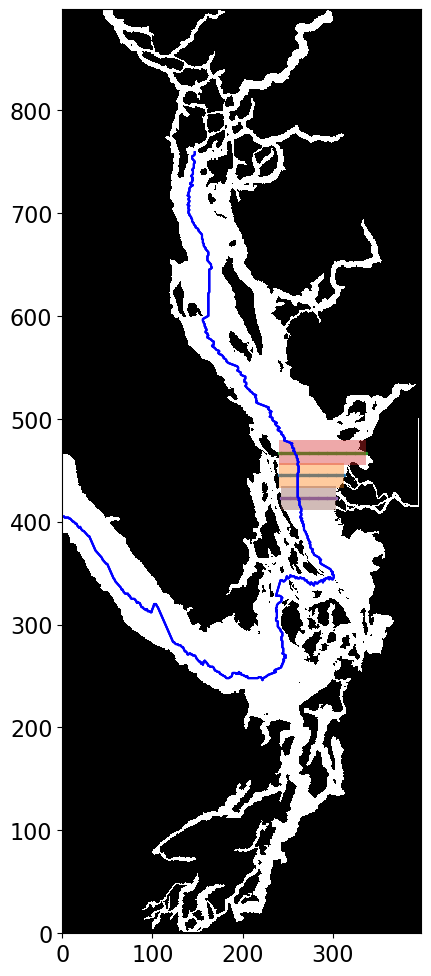

In [51]:
line_s = np.arange(240, s_x + 10)
line_y = [s_y] * len(line_s)
#
line_n = np.arange(240, s_x + 35)
line_yn = [s_y + 22] * len(line_n)
#
line_ss = np.arange(242, s_x + 2)
line_yss = [s_y - 22] * len(line_ss)
#
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
#
dd = 12
idx = 450
fig, ax = plt.subplots(figsize = (15,12))
ax.pcolormesh(mask['tmask'][0,0], cmap = cmap)
ax.set_aspect(1.14)
ax.plot(thalweg[:,1],thalweg[:,0],color='b')
ax.scatter(line_s, line_y, s = 2)
ax.fill_between(line_s, y1 = s_y-dd, y2 = s_y+dd, alpha = .4)
#
ax.plot(thalweg[:,1],thalweg[:,0],color='b')
ax.scatter(line_n, line_yn, s = 2)
ax.fill_between(line_n, y1 = s_y + 22-dd, y2 = s_y + 22+dd, alpha = .4)
#
#
ax.plot(thalweg[:,1],thalweg[:,0],color='b')
ax.scatter(line_ss, line_yss, s = 2)
ax.fill_between(line_ss, y1 = s_y - 22-dd, y2 = s_y - 22+dd, alpha = .4)


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. Distance Calculator aligned to a specific Reference X-index
def get_aligned_transect_dist(y_idx, x_start, x_end, ref_x, mask):
    lons = mask['nav_lon'].values[y_idx, x_start:x_end]
    lats = mask['nav_lat'].values[y_idx, x_start:x_end]
    
    # Calculate absolute cumulative distance from x_start
    dists = [0]
    for i in range(1, len(lons)):
        d_lat = lats[i] - lats[0]
        d_lon = (lons[i] - lons[0]) * np.cos(np.radians(lats[0]))
        distance_km = np.sqrt(d_lat**2 + d_lon**2) * 111.32
        dists.append(distance_km)
    
    dists = np.array(dists)
    
    # Shift the array so that ref_x is exactly 0 km
    ref_idx = int(ref_x) - x_start
    return dists - dists[ref_idx]

# 2. Flexible Slice Extractor
def extract_transect(data, mask, grid_3d, y_idx, x_start, x_end, dd=12, num_z_bins=40):
    tmask = mask['tmask'][0, 0].values
    y_start, y_end = max(0, y_idx - dd), min(grid_3d.shape[1], y_idx + dd + 1)
    
    num_x_steps = x_end - x_start
    transect_matrix = np.zeros((num_z_bins, num_x_steps))
    
    for idx_x, x_val in enumerate(range(x_start, x_end)):
        local_mask = tmask[y_start:y_end, x_val]
        for k in range(num_z_bins):
            box_counts = grid_3d[k, y_start:y_end, x_val]
            transect_matrix[k, idx_x] = np.sum(box_counts[local_mask == 1])
            
    return transect_matrix

In [69]:
import numpy as np

# 1. Extract and filter valid water particles
status = data['status'].values.flatten()
idx_wat = (status > 0) & (status < 4)

p_lons = data['lon'].values.flatten()[idx_wat]
p_lats = data['lat'].values.flatten()[idx_wat]
p_depths = data['z'].values.flatten()[idx_wat]

# 2. Convert Lat/Lon to Grid Indices using your KDTree function
print("Converting particle coordinates to grid indices...")
p_y, p_x = get_grid_indices_vectorized(p_lons, p_lats, mask)

# 3. Define the bins for the 3D Histogram
num_z_bins = 40
z_bins = np.linspace(0, 450, num_z_bins + 1)          # The vertical layers
y_bins = np.arange(0, mask.nav_lat.shape[0] + 1)      # The Y-axis (Latitude grid)
x_bins = np.arange(0, mask.nav_lat.shape[1] + 1)      # The X-axis (Longitude grid)

# 4. Generate the master 3D grid
print("Populating the 3D grid with particles...")
grid_3d, _ = np.histogramdd(
    (p_depths, p_y, p_x), 
    bins=(z_bins, y_bins, x_bins)
)

# Now you have z_bins, and you can calculate the centers for plotting
z_centers = (z_bins[:-1] + z_bins[1:]) / 2

Converting particle coordinates to grid indices...
Populating the 3D grid with particles...


In [70]:
# Setup the dictionary for your 3 locations
transects = {
    'North':  {'y': s_y + 22, 'x_start': 240, 'x_end': int(s_x + 32)},
    'Source':   {'y': s_y,      'x_start': 240, 'x_end': int(s_x + 10)},
    'South':  {'y': s_y - 22, 'x_start': 242, 'x_end': int(s_x+1)}
}

results = {}

for name, params in transects.items():
    y, xs, xe = params['y'], params['x_start'], params['x_end']
    
    # Calculate aligned distance (0 km at source)
    dist_km = get_aligned_transect_dist(y, xs, xe, ref_x=s_x, mask=mask)
    
    # Extract the data using the grid_3d we just built
    data_matrix = extract_transect(data, mask, grid_3d, y, xs, xe, dd=12)
    
    # Extract bathymetry
    bathy_raw = bathy['Bathymetry'][y, xs:xe].values
    bathy_smooth = np.convolve(bathy_raw, np.ones(5)/5, mode='same')
    bathy_smooth[0:2], bathy_smooth[-2:] = bathy_raw[0:2], bathy_raw[-2:]
    
    results[name] = {'dist': dist_km, 'data': data_matrix, 'bathy': bathy_smooth}

# Proceed to plotting...

/tmp/ipykernel_3751416/2910504575.py:57: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = ax_data.contourf(res['dist'], z_centers, res['data'],


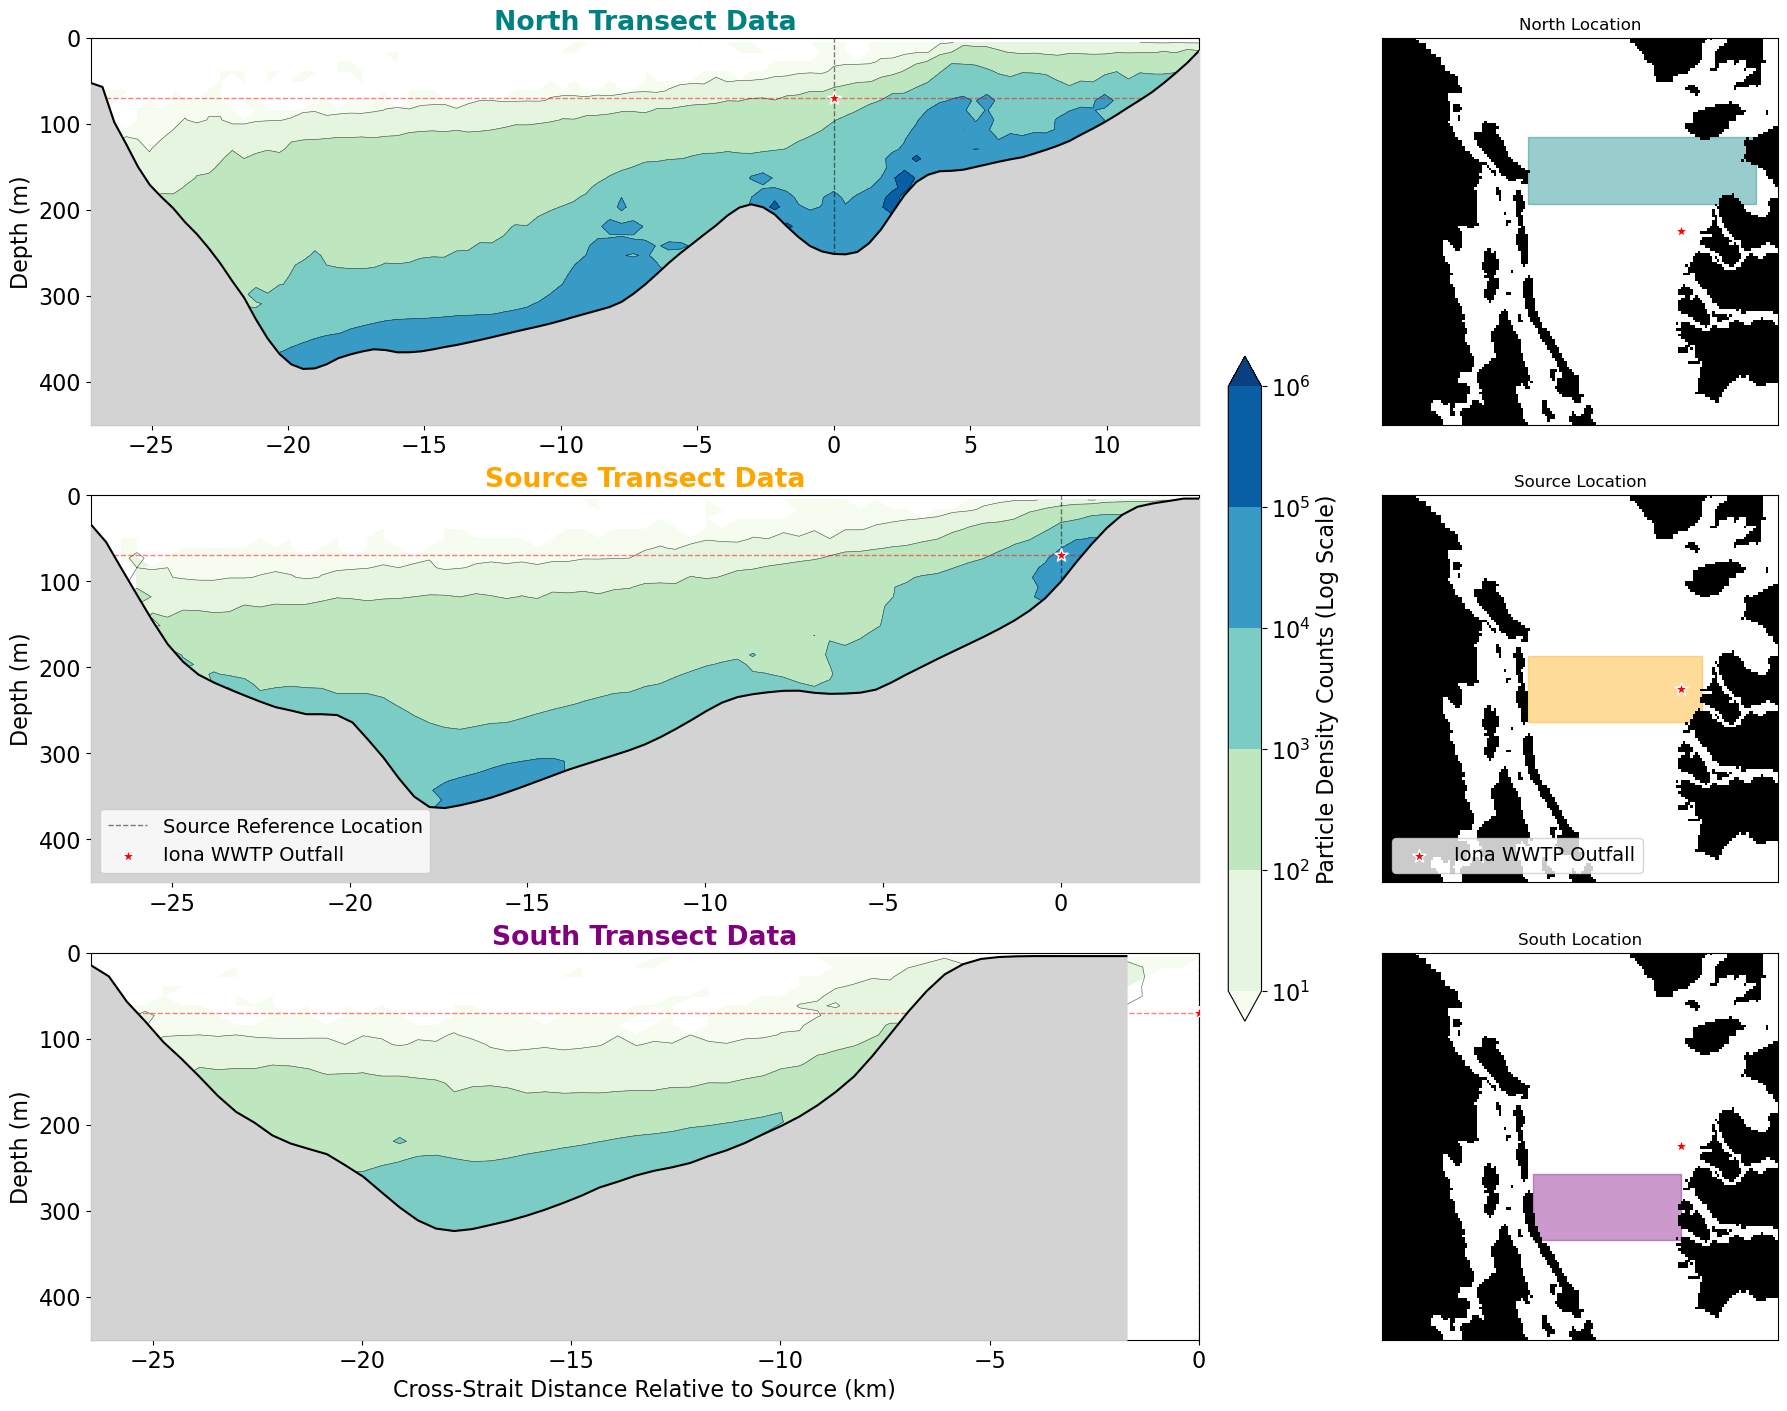

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
plt.rcParams.update({'font.size': 16})
# 1. Define Map Colors
colors_0 = [(0, 0, 0, 1), (0, 0, 0, 0)]  # Black for land, Transparent for water
cmap_mask = ListedColormap(colors_0)

# 2. Define Transect Parameters (matching your inputs)
dd = 12
transects = {
    'North': {
        'y': s_y + 22, 
        'x_start': 240, 
        'x_end': int(s_x + 32),
        'color': 'teal'
    },
    'Source': {
        'y': s_y,      
        'x_start': 240, 
        'x_end': int(s_x + 10),
        'color': 'orange'
    },
    'South': {
        'y': s_y - 22, 
        'x_start': 242, 
        'x_end': int(s_x+1),
        'color': 'purple'
    }
}

# Assume 'results' dictionary was populated using the previous extraction code
# results = {'North (+22)': {...}, 'Middle (0)': {...}, 'South (-22)': {...}}

# 3. Setup the 3x2 Figure
fig, axes = plt.subplots(
    3, 2, 
    figsize=(18, 14), 
    gridspec_kw={'width_ratios': [2.5, 1]}, # Data plots are 2.5x wider than maps
    layout='constrained'
)

levels = [10, 100, 1000, 10000, 100000, 1000000]
plot_order = ['North', 'Source', 'South']

for i, name in enumerate(plot_order):
    ax_data = axes[i, 0]  # Left column (Data)
    ax_map = axes[i, 1]   # Right column (Map)
    
    res = results[name]
    params = transects[name]
    t_color = params['color']
    
    # ==========================================
    # COLUMN 1: THE CROSS-STRAIT DATA PLOT
    # ==========================================
    cntr = ax_data.contourf(res['dist'], z_centers, res['data'], 
                            levels=levels, cmap='GnBu', 
                            norm=LogNorm(vmin=levels[0], vmax=levels[-1]), extend='both')
    
    ax_data.contour(res['dist'], z_centers, res['data'], 
                    levels=levels, colors='black', linewidths=0.4, alpha=0.7)
    # Seafloor
    ax_data.fill_between(res['dist'], res['bathy'], 450, color='lightgrey', zorder=3)
    ax_data.plot(res['dist'], res['bathy'], color='black', linewidth=1.5, zorder=4)
    
    # Formatting
    ax_data.invert_yaxis()
    ax_data.set_ylim(450, 0)
    ax_data.set_ylabel("Depth (m)")
    ax_data.set_title(f"{name} Transect Data", fontweight='bold', color=t_color)

    # ==========================================
    # COLUMN 2: THE REFERENCE MAP
    # ==========================================
    ax_map.pcolormesh(mask['tmask'][0,0], cmap=cmap_mask, zorder = 3)
    ax_map.set_aspect(1.14)
    
    # Plot Thalweg
    #ax_map.plot(thalweg[:,1], thalweg[:,0], color='blue', linewidth=1)
    ax_data.axvline(x = 0, color = 'k', linestyle = '--', linewidth = 1, alpha = .5, label = 'Source Reference Location')
    ax_data.axhline(y = 70, color = 'r', linestyle = '--', linewidth =1, alpha = .5)
    ax_data.scatter(0, 70, color = 'r', marker = '*', edgecolor = 'w', s = 100, zorder=5, label = 'Iona WWTP Outfall')

    #ax_data.axhline(y = 110, color = 'r', linestyle = '--', linewidth = 1, label = 'Source Reference Depth')

    # Plot Source Point
    ax_map.scatter(s_x, s_y, color='red', marker='*', edgecolor = 'w', s = 100, zorder=5, label = 'Iona WWTP Outfall')
    
    # Plot THIS specific transect line and box
    line_x = np.arange(params['x_start'], params['x_end'])
    line_y = [params['y']] * len(line_x)
    
    #ax_map.scatter(line_x, line_y, s=2, color=t_color)
    ax_map.fill_between(line_x, y1=params['y']-dd, y2=params['y']+dd, color=t_color, alpha=0.4, zorder = 2)
    
    # Zoom the map slightly around the Outfall region for visibility
    ax_map.set_xlim(180, s_x + 40)
    ax_map.set_ylim(s_y - 70, s_y + 70)
    
    # Clean up map axes
    ax_map.set_xticks([])
    ax_map.set_yticks([])
    ax_map.set_title(f"{name} Location", fontsize=12)
    #
    if i == 1:
        ax_data.legend(loc='lower left', fontsize = 14)
        ax_map.legend(loc='lower left', fontsize = 14)
    if i == 2:
        ax_data.set_xlabel("Cross-Strait Distance Relative to Source (km)")

# 4. Master Colorbar (Attached only to the left data column)
cbar = fig.colorbar(cntr, ax=axes[:, 0], orientation='vertical', fraction=0.03, pad=0.02, ticks=levels)
cbar.set_label('Particle Density Counts (Log Scale)')
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels])

plt.show()